Classes : 6  |  Total samples: 4788
  Client 0:   366 samples
  Client 1:   633 samples
  Client 2:   554 samples
  Client 3:   860 samples
  Client 4:  1418 samples
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]



  FedMA Federated Learning –Wheat
  Clients: 5  |  Rounds: 50  |  Local Epochs: 5
  Dirichlet alpha=0.5  |  SGD lr=0.001  momentum=0.9
  [Round 1] Client 0 done
  [Round 1] Client 1 done
  [Round 1] Client 2 done
  [Round 1] Client 3 done
  [Round 1] Client 4 done
>>> Round  1 | Acc=0.7388  Prec=0.8222  Rec=0.7325  F1=0.6747

  [Round 2] Client 0 done
  [Round 2] Client 1 done
  [Round 2] Client 2 done
  [Round 2] Client 3 done
  [Round 2] Client 4 done
>>> Round  2 | Acc=0.8725  Prec=0.8933  Rec=0.8694  F1=0.8564

  [Round 3] Client 0 done
  [Round 3] Client 1 done
  [Round 3] Client 2 done
  [Round 3] Client 3 done
  [Round 3] Client 4 done
>>> Round  3 | Acc=0.9133  Prec=0.9246  Rec=0.9112  F1=0.9067

  [Round 4] Client 0 done
  [Round 4] Client 1 done
  [Round 4] Client 2 done
  [Round 4] Client 3 done
  [Round 4] Client 4 done
>>> Round  4 | Acc=0.9331  Prec=0.9409  Rec=0.9317  F1=0.9296

  [Round 5] Client 0 done
  [Round 5] Client 1 done
  [Round 5] Client 2 done
  [Round 5] Cl

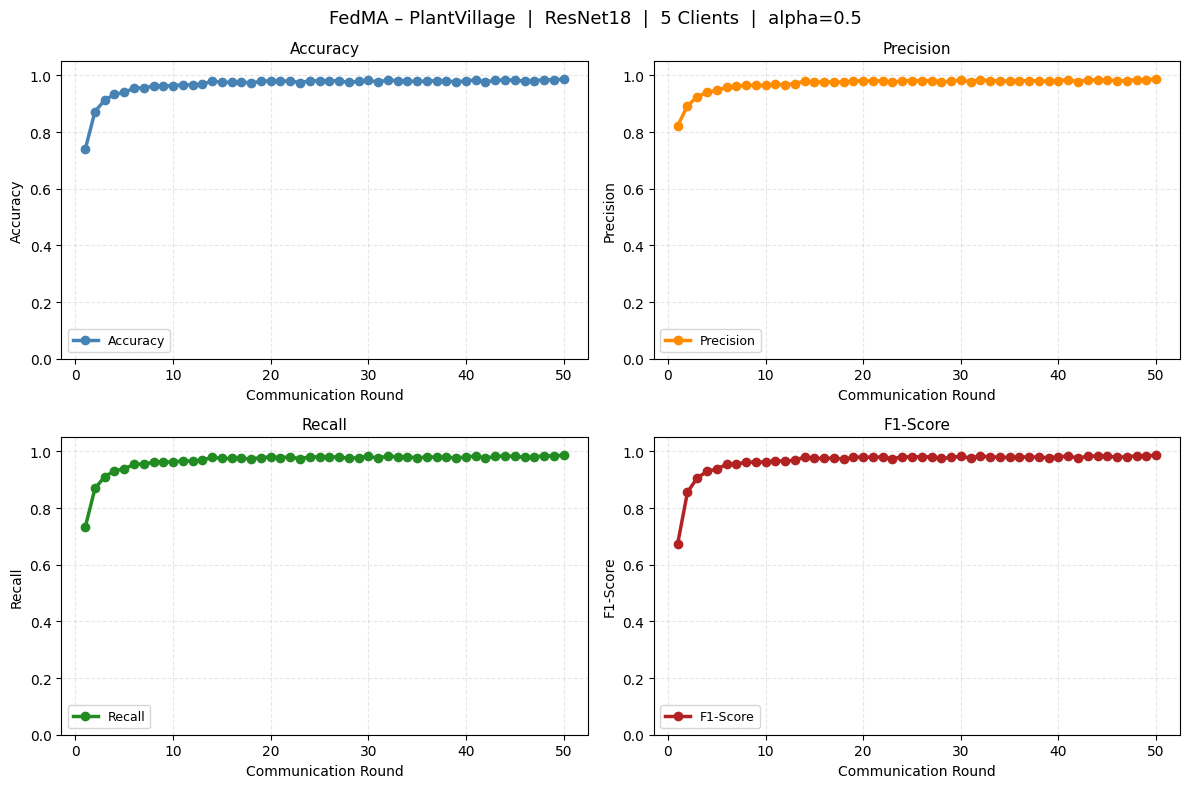


All outputs saved under /kaggle/working:
  - /kaggle/working/fedma_metrics.csv
  - /kaggle/working/fedma_checkpoint.json
  - /kaggle/working/fedma_confusion_matrices/round_XXX.txt
  - /kaggle/working/fedma_global_model.pth
  - fedma_results.png


In [1]:
# ============================================================
# FedMA on Cotton Dataset - Kaggle Notebook
# Paper: "Federated Learning with Matched Averaging" (ICLR 2020)
# Settings: ResNet18, 5 clients, Dirichlet alpha=0.5, 50 rounds, 5 local epochs
#
# Engineering pattern matches your other 4 algorithms:
#   - per-round CSV append (survives Kaggle timeouts)
#   - rolling JSON checkpoint
#   - confusion matrix saved as formatted text each round
#   - strict CPU-storage / GPU-compute contract for state dicts
# ============================================================

# Cell 1: Imports
import os, copy, json, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# Cell 2: Config
# ------------------------------------------------------------
class CFG:
    # Candidate paths -- auto-detected in Cell 3. Kaggle's PlantVillage
    # dataset has appeared under more than one layout depending on which
    # upload is attached, so we no longer hardcode a single path.
    DATA_ROOT = "/kaggle/input/datasets/dhamur/cotton-plant-disease/Cotton leaves/40 Images"
    
    NUM_CLIENTS  = 5
    ALPHA        = 0.5
    NUM_ROUNDS   = 10          # set to 10 for a quick smoke-test run
    LOCAL_EPOCHS = 5
    BATCH_SIZE   = 32
    LR           = 0.001
    MOMENTUM     = 0.9
    IMG_SIZE     = 224
    SEED         = 42
    SAVE_DIR     = "/kaggle/working"
    DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

set_seed(CFG.SEED)
os.makedirs(CFG.SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Cell 3: Resolve dataset path (auto-detect + explicit failure msg)
# ------------------------------------------------------------
if not os.path.isdir(CFG.DATA_ROOT):
    raise FileNotFoundError(
        f"Dataset not found at {CFG.DATA_ROOT}. "
        f"Check that the PlantVillage dataset is attached via 'Add Input'."
    )

# ------------------------------------------------------------
# Cell 4: Dataset and Non-IID Dirichlet split
# ------------------------------------------------------------
transform_train = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
transform_val = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

full_dataset = ImageFolder(root=CFG.DATA_ROOT, transform=transform_train)
class_names  = full_dataset.classes
num_classes  = len(class_names)
print(f"Classes : {num_classes}  |  Total samples: {len(full_dataset)}")

val_size   = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size
all_indices = list(range(len(full_dataset)))
rng_split   = np.random.default_rng(CFG.SEED)
shuffled    = rng_split.permutation(all_indices).tolist()
train_idx   = shuffled[:train_size]
val_idx     = shuffled[train_size:]

labels = np.array(full_dataset.targets)

def dirichlet_split(indices, labels, n_clients, alpha, seed=42):
    rng     = np.random.default_rng(seed)
    cls_ids = {}
    for i in indices:
        c = int(labels[i])
        cls_ids.setdefault(c, []).append(i)
    client_ids = [[] for _ in range(n_clients)]
    for c in sorted(cls_ids.keys()):
        ids = cls_ids[c]
        rng.shuffle(ids)
        proportions = rng.dirichlet([alpha] * n_clients)
        proportions = proportions / proportions.sum()
        splits = (proportions * len(ids)).astype(int)
        splits[-1] = len(ids) - int(splits[:-1].sum())
        splits = np.maximum(splits, 0)
        ptr = 0
        for k, sz in enumerate(splits):
            client_ids[k].extend(ids[ptr:ptr + int(sz)])
            ptr += int(sz)
    return client_ids

client_train_idx = dirichlet_split(train_idx, labels, CFG.NUM_CLIENTS, CFG.ALPHA, CFG.SEED)
for k, ids in enumerate(client_train_idx):
    print(f"  Client {k}: {len(ids):5d} samples")

def get_client_loader(client_idx):
    ds  = ImageFolder(root=CFG.DATA_ROOT, transform=transform_train)
    sub = Subset(ds, client_idx)
    return DataLoader(sub, batch_size=CFG.BATCH_SIZE, shuffle=True,
                       num_workers=2, pin_memory=True)

def get_val_loader():
    ds  = ImageFolder(root=CFG.DATA_ROOT, transform=transform_val)
    sub = Subset(ds, val_idx)
    return DataLoader(sub, batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
                       num_workers=2, pin_memory=True)

val_loader = get_val_loader()

# ------------------------------------------------------------
# Cell 5: Model
# ------------------------------------------------------------
def build_model(num_cls):
    m = torchvision.models.resnet18(
        weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, num_cls)
    return m.to(CFG.DEVICE)

def state_dict_to_cpu(sd):
    """Strict CPU-storage contract: everything cached between rounds lives
    on CPU; only the active model/batch tensors live on GPU."""
    return {k: v.detach().to('cpu') for k, v in sd.items()}

# ------------------------------------------------------------
# Cell 6: Local training
# ------------------------------------------------------------
def local_train(model, loader, epochs, lr, momentum):
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    criterion = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(CFG.DEVICE), lbls.to(CFG.DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward()
            optimizer.step()
    return model

# ------------------------------------------------------------
# Cell 7: Evaluation
# ------------------------------------------------------------
def evaluate(model, loader):
    model.eval()
    all_preds, all_lbls = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs  = imgs.to(CFG.DEVICE)
            preds = model(imgs).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_lbls.extend(lbls.numpy())
    acc  = accuracy_score(all_lbls, all_preds)
    prec = precision_score(all_lbls, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_lbls, all_preds, average='macro', zero_division=0)
    f1   = f1_score(all_lbls, all_preds, average='macro', zero_division=0)
    cm   = confusion_matrix(all_lbls, all_preds)
    return acc, prec, rec, f1, cm

def format_confusion_matrix(cm, class_names):
    """Format varies by class count, consistent with your other scripts."""
    n = len(class_names)
    lines = []
    if n <= 10:
        header = "        " + " ".join(f"{c[:6]:>6}" for c in class_names)
        lines.append(header)
        for i, row in enumerate(cm):
            lines.append(f"{class_names[i][:6]:>6}: " + " ".join(f"{v:6d}" for v in row))
    elif n <= 25:
        lines.append("Confusion matrix (row=true, col=pred), classes truncated to 10 chars:")
        header = " ".join(f"{i:>4}" for i in range(n))
        lines.append("     " + header)
        for i, row in enumerate(cm):
            lines.append(f"{i:>4}: " + " ".join(f"{v:4d}" for v in row))
        lines.append("\nClass index legend:")
        for i, c in enumerate(class_names):
            lines.append(f"  {i:>3} = {c}")
    else:
        lines.append(f"Confusion matrix too large to print in full ({n} classes).")
        lines.append("Per-class diagonal (true positives) and row totals:")
        for i, c in enumerate(class_names):
            tp = cm[i, i]
            total = cm[i].sum()
            lines.append(f"  {c}: {tp}/{total} correct")
    return "\n".join(lines)

# ------------------------------------------------------------
# Cell 8: FedMA – Hungarian neuron-matching aggregation
# ------------------------------------------------------------
def hungarian_match(ref_w, cli_w):
    ref_flat = ref_w.reshape(ref_w.shape[0], -1)
    cli_flat = cli_w.reshape(cli_w.shape[0], -1)
    norm_ref = ref_flat / (np.linalg.norm(ref_flat, axis=1, keepdims=True) + 1e-8)
    norm_cli = cli_flat / (np.linalg.norm(cli_flat, axis=1, keepdims=True) + 1e-8)
    cost   = -(norm_ref @ norm_cli.T)
    _, col = linear_sum_assignment(cost)
    return col

def fedma_aggregate(global_model, local_state_dicts):
    """
    local_state_dicts are expected to already be on CPU (see
    state_dict_to_cpu), per the CPU-storage/GPU-compute contract.
    """
    global_sd = global_model.state_dict()
    new_sd    = copy.deepcopy(global_sd)

    weight_keys = [
        k for k in global_sd
        if 'weight' in k and global_sd[k].dim() >= 2 and 'fc' not in k
    ]

    for wk in weight_keys:
        ref_np = global_sd[wk].cpu().float().numpy()
        matched_w, perms = [], []
        for cli_sd in local_state_dicts:
            if wk not in cli_sd:
                continue
            cli_np = cli_sd[wk].float().numpy()
            if cli_np.shape == ref_np.shape:
                perm = hungarian_match(ref_np, cli_np)
                matched_w.append(cli_np[perm])
                perms.append(perm)
            else:
                matched_w.append(cli_np)
                perms.append(np.arange(cli_np.shape[0]))

        if matched_w:
            new_sd[wk] = torch.tensor(np.mean(matched_w, axis=0), dtype=global_sd[wk].dtype)

        bk = wk.replace('weight', 'bias')
        if bk in global_sd and global_sd[bk].dim() == 1:
            matched_b = []
            for cli_sd, perm in zip(local_state_dicts, perms):
                if bk in cli_sd:
                    b = cli_sd[bk].float().numpy()
                    matched_b.append(b[perm] if len(b) == len(perm) else b)
            if matched_b:
                new_sd[bk] = torch.tensor(np.mean(matched_b, axis=0), dtype=global_sd[bk].dtype)

    bn_keys = [
        k for k in global_sd
        if ('bn' in k or 'downsample.1' in k)
        and global_sd[k].is_floating_point()
        and k not in weight_keys
    ]
    for bnk in bn_keys:
        vals = [cli[bnk].float() for cli in local_state_dicts if bnk in cli]
        if vals:
            new_sd[bnk] = torch.stack(vals).mean(0).to(global_sd[bnk].dtype)

    fc_keys = [k for k in global_sd if 'fc' in k]
    for fck in fc_keys:
        vals = [cli[fck].float() for cli in local_state_dicts if fck in cli]
        if vals:
            new_sd[fck] = torch.stack(vals).mean(0).to(global_sd[fck].dtype)

    global_model.load_state_dict(new_sd)
    return global_model

# ------------------------------------------------------------
# Cell 9: Federated Training Loop with per-round persistence
# ------------------------------------------------------------
global_model = build_model(num_classes)

csv_path        = os.path.join(CFG.SAVE_DIR, "fedma_metrics.csv")
json_ckpt_path  = os.path.join(CFG.SAVE_DIR, "fedma_checkpoint.json")
cm_dir          = os.path.join(CFG.SAVE_DIR, "fedma_confusion_matrices")
model_ckpt_path = os.path.join(CFG.SAVE_DIR, "fedma_global_model.pth")
os.makedirs(cm_dir, exist_ok=True)

# Resume support: if a checkpoint exists, pick up where we left off
start_round = 1
results     = []
if os.path.exists(json_ckpt_path):
    with open(json_ckpt_path, "r") as f:
        ckpt = json.load(f)
    results     = ckpt.get("results", [])
    start_round = ckpt.get("last_round", 0) + 1
    if start_round > 1 and os.path.exists(model_ckpt_path):
        global_model.load_state_dict(torch.load(model_ckpt_path, map_location=CFG.DEVICE))
        print(f"Resumed from checkpoint at round {start_round - 1}")

print("\n" + "=" * 60)
print("  FedMA Federated Learning –Wheat")
print(f"  Clients: {CFG.NUM_CLIENTS}  |  Rounds: {CFG.NUM_ROUNDS}  |  Local Epochs: {CFG.LOCAL_EPOCHS}")
print(f"  Dirichlet alpha={CFG.ALPHA}  |  SGD lr={CFG.LR}  momentum={CFG.MOMENTUM}")
print("=" * 60)

for rnd in range(start_round, CFG.NUM_ROUNDS + 1):
    local_sds = []

    for k in range(CFG.NUM_CLIENTS):
        local_m  = copy.deepcopy(global_model).to(CFG.DEVICE)
        loader_k = get_client_loader(client_train_idx[k])
        local_m  = local_train(local_m, loader_k, CFG.LOCAL_EPOCHS, CFG.LR, CFG.MOMENTUM)
        local_sds.append(state_dict_to_cpu(local_m.state_dict()))
        print(f"  [Round {rnd}] Client {k} done")
        del local_m
        if CFG.DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    global_model = fedma_aggregate(global_model, local_sds)

    acc, prec, rec, f1, cm = evaluate(global_model, val_loader)
    row = {"Round": rnd, "Accuracy": acc, "Precision": prec,
           "Recall": rec, "F1-Score": f1}
    results.append(row)
    print(f">>> Round {rnd:2d} | Acc={acc:.4f}  Prec={prec:.4f}  "
          f"Rec={rec:.4f}  F1={f1:.4f}\n")

    # --- per-round persistence (guards against Kaggle session timeouts) ---
    pd.DataFrame([row]).to_csv(
        csv_path, mode='a', header=not os.path.exists(csv_path), index=False)

    with open(json_ckpt_path, "w") as f:
        json.dump({"last_round": rnd, "results": results}, f, indent=2)

    with open(os.path.join(cm_dir, f"round_{rnd:03d}.txt"), "w") as f:
        f.write(format_confusion_matrix(cm, class_names))

    torch.save(global_model.state_dict(), model_ckpt_path)

# ------------------------------------------------------------
# Cell 10: Final results and plots
# ------------------------------------------------------------
df = pd.DataFrame(results)
print("\n--- FedMA Final Metrics Across Rounds ---")
print(df.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("FedMA – PlantVillage  |  ResNet18  |  5 Clients  |  alpha=0.5", fontsize=13)
for ax, m, c in zip(axes.flat,
                     ["Accuracy", "Precision", "Recall", "F1-Score"],
                     ["steelblue", "darkorange", "forestgreen", "firebrick"]):
    ax.plot(df["Round"], df[m], marker='o', color=c, linewidth=2.5,
            markersize=6, label=m)
    ax.set_title(m, fontsize=11)
    ax.set_xlabel("Communication Round")
    ax.set_ylabel(m)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CFG.SAVE_DIR, "fedma_results.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAll outputs saved under {CFG.SAVE_DIR}:")
print(f"  - {csv_path}")
print(f"  - {json_ckpt_path}")
print(f"  - {cm_dir}/round_XXX.txt")
print(f"  - {model_ckpt_path}")
print(f"  - fedma_results.png")